
# ***Analysis of operational performance and marketing effectiveness for a chain of chocolate shops***

Project objective

To conduct a comprehensive sales audit, identify key profit-driving regions, and assess how discounts and the loyalty programme impact the company’s financial performance.
Data description:

There are 5 relational tables available:
* **Sales**: transaction data (dates, quantity, revenue, profit, discounts)
* **Products**: product directory (brands, categories, cocoa content)
* **Stores**: information on points of sale (countries, cities, shop types)
* **Customers**: customer profiles (age, gender, loyalty status).
* **Calendar**: a calendar grid for analysing seasonality.

Technology stack:
`Python,
Pandas (data processing),
Matplotlib (visualisation),
Ticker (professional chart formatting).`

Key research questions:
* Geography: Which countries generate the majority of revenue?
* Seasonality: In which months do peaks and troughs in activity occur?
* Marketing: Are discounts paying off, and how do loyalty programme members behave?
* Demographics: Who is our main customer in terms of age?


Technical specifications

In [6]:
from itertools import groupby

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

calendar  = pd.read_csv("calendar.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")
stores = pd.read_csv("stores.csv")

dataframes=[calendar, customers, products, sales, stores]

In [7]:
sum_prof = sales["profit"].sum()
print(sum_prof)
sales.head()

10194564.629999999


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [8]:
print(stores.isnull().sum())
for i in dataframes:
    print(i.duplicated().sum())

store_id      0
store_name    0
city          0
country       0
store_type    0
dtype: int64
0
0
0
0
0


**Geographical data:**

* Quantity of sales in every country
* Profit for every country
* Most popular store type

In [9]:
merged_df = pd.merge(sales, stores, on='store_id')

city_sales = merged_df.groupby('country')['quantity'].sum().reset_index()
ct_quant = city_sales.sort_values(by='quantity', ascending=False)
ct_quant.head()


,country,quantity
1,Canada,599270
4,UK,567747
5,USA,510229
2,France,510035
0,Australia,451891


In [10]:
df = sales.merge(stores, on='store_id')

result = df.groupby(['country', 'store_type'])['store_id'].nunique(). reset_index()
result.columns = ['country', 'store_type', 'count']

top = result.sort_values(['country', 'count'], ascending=[True, False]).drop_duplicates('country')

print(top.sort_values('count', ascending=False))

      country store_type  count
15         UK    Airport      9
12    Germany    Airport      8
6      Canada     Online      7
9      France       Mall      6
21        USA     Online      6
1   Australia       Mall      5


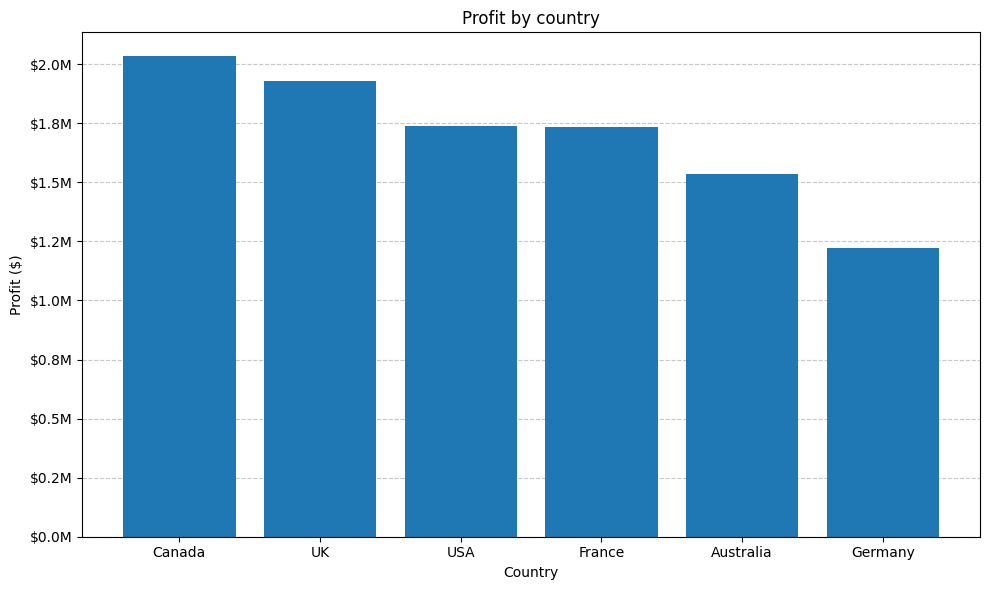

In [11]:
counrty_profit_plt = merged_df.groupby('country')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(counrty_profit_plt.index, counrty_profit_plt.values)

def millions_formatter(x, pos):
    return f'${x / 1e6:.1f}M'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))

plt.title('Profit by country')
plt.xlabel('Country')
plt.ylabel('Profit ($)')

plt.tight_layout()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

plt.show()

In [12]:
unique = stores['store_type'].drop_duplicates()
unique_sum = stores.groupby('store_type').value_counts()
print(unique_sum)
unique_sum = stores.groupby('store_type').size().sort_values(ascending=False)
print(unique_sum)

store_type  store_id  store_name          city       country  
Airport     S050      Chocolate Store 50  New York   Canada       1
            S030      Chocolate Store 30  New York   UK           1
            S040      Chocolate Store 40  Melbourne  Canada       1
            S041      Chocolate Store 41  London     Germany      1
            S043      Chocolate Store 43  London     Germany      1
                                                                 ..
Retail      S011      Chocolate Store 11  New York   USA          1
            S065      Chocolate Store 65  New York   Australia    1
            S069      Chocolate Store 69  London     France       1
            S052      Chocolate Store 52  Toronto    France       1
            S001      Chocolate Store 1   New York   Canada       1
Name: count, Length: 100, dtype: int64
store_type
Airport    30
Mall       26
Online     25
Retail     19
dtype: int64


Conclusion:
Canada and the United Kingdom offer the greatest potential; these should be the main focus.

Although they are not the most populous countries, they consume the most

**Seasonality Analysis: Monthly Sales Performance**

Quantity of sales in every month



In [13]:
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

df = sales.merge(calendar[['date', 'month']], left_on='order_date', right_on='date')

result = df.groupby('month').size().rename(index=month_names)

result.sort_values(ascending=False)

month
January      85375
May          85024
March        84968
July         84940
August       84933
October      84721
December     84665
September    82465
June         81793
November     81721
April        81612
February     77783
dtype: int64

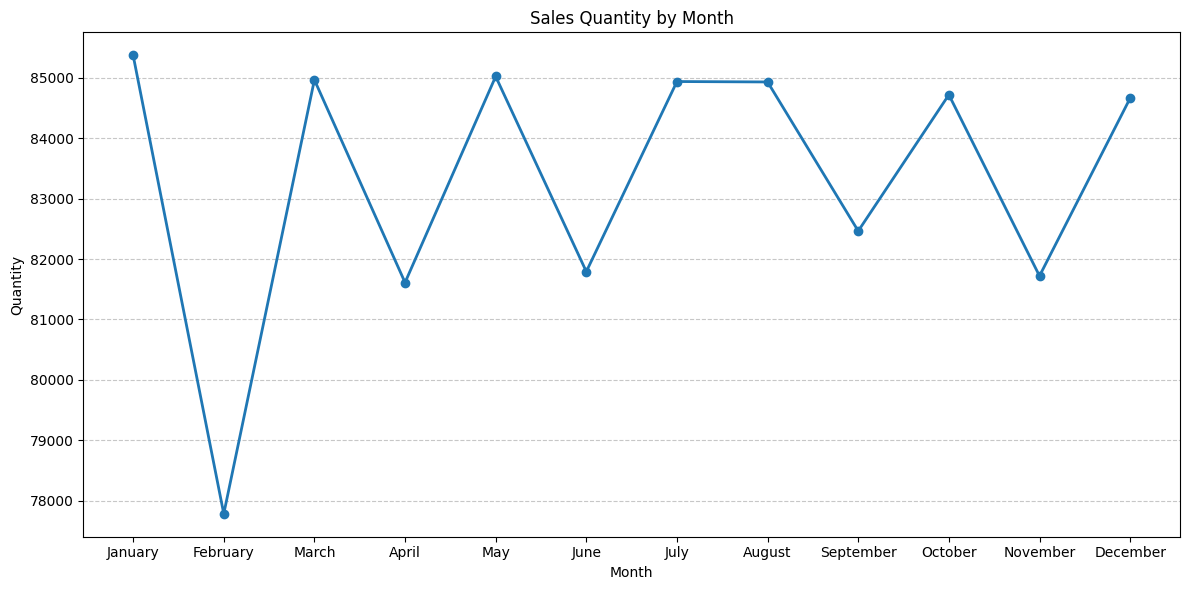

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(result.index, result.values, marker='o', linestyle='-', linewidth=2)

plt.title('Sales Quantity by Month')
plt.xlabel('Month')
plt.ylabel('Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

The shop’s range includes "200" unique items. The data has been checked for integrity: each ID corresponds to a unique product name

In [21]:
sales['year'] = pd.to_datetime(sales['order_date']).dt.year
sales['month'] = pd.to_datetime(sales['order_date']).dt.month
month_rev2 = sales.groupby(['year', 'month'])['revenue'].sum()
print(month_rev2)

year  month
2023  1        1095019.20
      2         968948.95
      3        1084656.09
      4        1038425.32
      5        1083418.79
      6        1046045.02
      7        1083223.13
      8        1086689.94
      9        1056935.75
      10       1071879.65
      11       1039418.12
      12       1080446.31
2024  1        1084751.00
      2        1010042.22
      3        1084560.82
      4        1043453.14
      5        1078643.18
      6        1038214.24
      7        1085923.34
      8        1082353.60
      9        1051414.03
      10       1075082.20
      11       1039335.10
      12       1077249.72
Name: revenue, dtype: float64


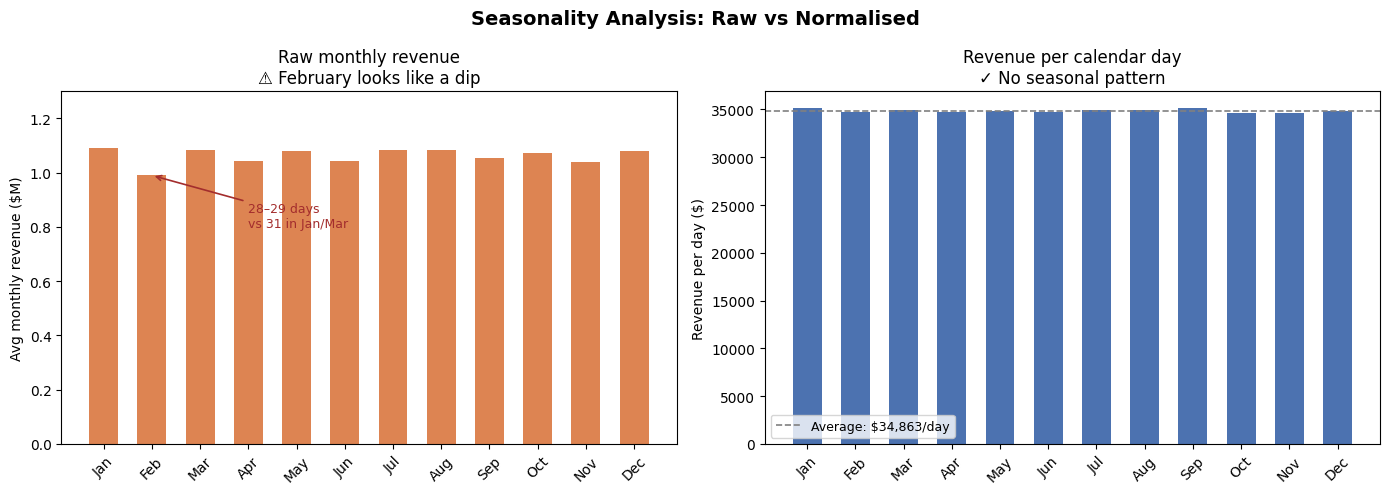

In [22]:
import calendar as cal_module

sales['order_date']  = pd.to_datetime(sales['order_date'])
sales['year'] = sales['order_date'].dt.year
sales['month'] = sales['order_date'].dt.month
sales['days_in_month'] = sales['order_date'].dt.days_in_month

month_rev3 = sales.groupby(['year', 'month']).agg(
revenue= ('revenue','sum'),
days_in_month=('days_in_month', 'first')
).reset_index()
month_rev3['revenue_per_day'] = month_rev3['revenue'] / month_rev3['days_in_month']

monthly_avg = month_rev3.groupby('month').agg(
raw_revenue=('revenue','mean'),
revenue_per_day=('revenue_per_day','mean')
).reset_index()
monthly_avg['month_name'] = monthly_avg['month'].apply(lambda m: cal_module.month_abbr[m])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seasonality Analysis: Raw vs Normalised', fontsize=14, fontweight='bold')

x      = range(len(monthly_avg))
months = monthly_avg['month_name']

axes[0].bar(x, monthly_avg['raw_revenue'] / 1e6, color='#DD8452', width=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(months, rotation=45)
axes[0].set_ylabel('Avg monthly revenue ($M)')
axes[0].set_title('Raw monthly revenue\n⚠ February looks like a dip')
axes[0].set_ylim(0, 1.3)
axes[0].annotate('28–29 days\nvs 31 in Jan/Mar',
                 xy=(1, monthly_avg.loc[monthly_avg['month'] == 2, 'raw_revenue'].values[0] / 1e6),
                 xytext=(3, 0.8), fontsize=9, color='#A32D2D',
                 arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.2))

baseline = monthly_avg['revenue_per_day'].mean()
axes[1].bar(x, monthly_avg['revenue_per_day'], color='#4C72B0', width=0.6)
axes[1].axhline(y=baseline, color='gray', linestyle='--', linewidth=1.2,
                label=f'Average: ${baseline:,.0f}/day')
axes[1].set_xticks(x)
axes[1].set_xticklabels(months, rotation=45)
axes[1].set_ylabel('Revenue per day ($)')
axes[1].set_title('Revenue per calendar day\n✓ No seasonal pattern')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
sales['days_in_month'] = pd.to_datetime(sales['order_date']).dt.days_in_month

month_rev3 = sales.groupby(['year', 'month']).agg(
    revenue=('revenue', 'sum'),
    days=('days_in_month', 'first')
).reset_index()

month_rev3['revenue_per_day'] = month_rev3['revenue'] / month_rev3['days']
print(month_rev3)

**Conclusion:**

* Peak Demand: The highest transaction volume is recorded in January...

* Annual Low: Sales reach their lowest point in February...

* Business Insight: To counter the February dip... Valentine's Day products...

**Brand Performance**: Profitability and Popularity Audit

In [ ]:
df_prod_sales = pd.merge(products,sales, on = 'product_id')
df_prod_sales.head()
df_brand_price = df_prod_sales.groupby('brand')['profit'].sum().sort_values(ascending=False).reset_index()
print(df_brand_price)

In [ ]:
df_prod_sales.head()
brand_ord = df_prod_sales.groupby('brand')['order_id'].size().sort_values(ascending=False)
brand_ord_unique = df_prod_sales.groupby('brand')['order_id'].nunique().sort_values(ascending=False)
print(brand_ord_unique,brand_ord)

In [ ]:
df_prod_sales.head()
unit_price_brand = df_prod_sales.groupby('brand')['unit_price'].mean().sort_values(ascending=False)
print(unit_price_brand)

In [ ]:
brand_profit = df_prod_sales.groupby('brand')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(brand_profit.index, brand_profit.values)
plt.title('Profit by brand', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Profit')
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)
plt.tight_layout()
plt.show()

In [ ]:
category_popularity = pd.merge(products, sales, on = 'product_id')
category_popularity.head()
category_mid = category_popularity.groupby('category')['profit'].sum().sort_values(ascending=False)
category_mid.head()
brand_popularity = category_popularity.groupby(['brand', 'category'])['profit'].sum().reset_index()

brand_popularity = brand_popularity.sort_values('profit', ascending=False)

brand_top_chocolate = brand_popularity.drop_duplicates('brand')
print(brand_top_chocolate)

In [ ]:
import matplotlib.pyplot as plt

labels = [f"{b} ({c})" for b, c in zip(brand_top_chocolate['brand'], brand_top_chocolate['category'])]
values = brand_top_chocolate['profit']

plt.figure(figsize=(10, 6))
plt.barh(labels, values, color='skyblue')

plt.xlabel('Profit')
plt.title('Top chocolates by brand and category')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Market Leaders**: Ferrero and Cadbury are the primary profit drivers, generating $1.87M and $1.86M respectively.

**Customer Favorites**: Ferrero also leads in transaction volume with 183,603 orders, showing high brand loyalty.

**Premium Segment**: Lindt maintains the highest average unit price ($9.01), positioning it as the top-tier premium brand in the portfolio.

**Strategic Insight**: The Praline category (Mars/Cadbury) and Dark chocolate (Ferrero) are the most profitable niches; focus marketing efforts on these high-margin segments.

**Loyalty Program Impact**: Financial Performance and Customer Behavior

In [ ]:

count = (customers['loyalty_member'] == 1).sum()
print(count)
count1 = (customers['loyalty_member'] == 0).sum()
print(count1)
a = customers['loyalty_member'].value_counts()
print(a)
customer_lol = pd.merge(customers, sales, on='customer_id')
customer_lol.head()

cus_lot = customer_lol.groupby('loyalty_member').agg(
    total_profit=('profit', 'sum'),
    avg_profit=('profit', 'mean'),
    orders=('order_id', 'count')
).reset_index()

print(cus_lot)

In [ ]:

cus_lot['loyalty_status'] = cus_lot['loyalty_member'].map({1: 'Member', 0: 'Non-Member'})

plt.figure(figsize=(10, 6))
bars = plt.bar(cus_lot['loyalty_status'], cus_lot['total_profit'])


def millions(x, pos):
    return f'${x / 1e6:.1f}M'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(millions))

plt.title('Total Profit: Loyalty Members vs Non-Members')
plt.ylabel('Total Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

**Equal Contribution**: Loyalty members and non-members contribute almost equally to total profit, generating $5.11M and $5.09M respectively.

**High Engagement**: The transaction count is nearly identical between groups (~500k orders each), suggesting the loyalty program has reached a significant portion of the active customer base.

**Profit Stability**: Average profit per order is consistent across both groups at approximately $10.20, indicating that loyalty rewards are not significantly eroding profit margins.

**Strategic Opportunity**: Since members do not yet spend significantly more than non-members, there is an opportunity to introduce exclusive high-value tiers to increase the "average check" for loyalists.

**Promotion Effectiveness**: Impact of Discounts on Sales Volume and Profitability

**Demographic Analysis**: Age Group

In [ ]:

discount_analysis = sales.groupby('discount').agg(
    avg_profit_per_order=('profit', 'mean'),
    profit_margin=('profit', lambda x: x.sum() / sales.loc[x.index, 'revenue'].sum()),
    sales_count=('order_id', 'nunique')
).reset_index()

baseline = discount_analysis.loc[discount_analysis['discount'] == 0.0, 'avg_profit_per_order'].values[0]
discount_analysis['profit_loss_pct'] = (discount_analysis['avg_profit_per_order'] / baseline - 1) * 100

print(discount_analysis[['discount', 'avg_profit_per_order', 'profit_margin', 'sales_count', 'profit_loss_pct']].to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Discount Impact Analysis', fontsize=14, fontweight='bold')

labels = [f"{int(d*100)}%" for d in discount_analysis['discount']]
x = range(len(labels))

# График 1: абсолютный profit падает
colors = ['#4C72B0' if d == 0.0 else '#DD8452' for d in discount_analysis['discount']]
bars = axes[0].bar(x, discount_analysis['avg_profit_per_order'], color=colors, width=0.5)
for bar, val in zip(bars, discount_analysis['avg_profit_per_order']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'${val:.2f}', ha='center', va='bottom', fontsize=10)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Avg profit per order\n(drops with higher discounts)')
axes[0].set_ylabel('Avg profit ($)')
axes[0].set_ylim(0, 13)

# График 2: margin стабильна
axes[1].bar(x, discount_analysis['profit_margin'] * 100, color='#55A868', width=0.5)
for i, val in enumerate(discount_analysis['profit_margin'] * 100):
    axes[1].text(i, val + 0.1, f'{val:.2f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Profit margin %\n(stable — discount is already in revenue)')
axes[1].set_ylabel('Profit margin (%)')
axes[1].set_ylim(0, 55)

plt.tight_layout()
plt.show()

In [ ]:
bins = [0, 30, 45, 60, 120]
labels = ['18-30', '31-45', '46-60', '60+']

customer_sales_merge = pd.merge(customers, sales, on='customer_id')
customer_sales_merge['age_group'] = pd.cut(customer_sales_merge['age'], bins=bins, labels=labels)
age_profit_analysis = customer_sales_merge.groupby('age_group')['profit'].mean()

print("Average profit per purchase by age group:")
print(age_profit_analysis)

final_report = customer_sales_merge.groupby('age_group')['profit'].agg(['mean', 'count'])

print(final_report)

**Two-sided discount story:**

- **Absolute profit drops**: avg profit per order falls from $10.81 (no discount) to $8.64 at 20% — a real 20% revenue loss per transaction.
- **Margin stays stable**: profit margin holds at ~40% across all tiers. This is expected — the discount is already baked into revenue, so both sides of the ratio shrink proportionally.
- **Volume doesn't compensate**: discounted tiers each generate ~125K orders vs 625K at no discount — discounts are not driving meaningful incremental volume.
- **Recommendation**: cap discounts at 10% or restructure as loyalty rewards rather than blanket price cuts.

# **Executive Summary**

This analysis covers 1,000,000 transactions across 6 countries and 2 years (2023–2024).

**Key Findings:**

* Geography: Canada and UK are the top markets, generating $2,143,450 and $2,028,217 in profit respectively. Germany is the weakest market, heavily dependent on Airport stores.

*  Brands: Ferrero leads in total profit ($1.87M) driven by transaction volume (183,603 orders), not price — all brands have nearly identical average unit prices (~$9.00).

*  Categories: Praline is the most profitable category ($2,829,380), while Milk chocolate underperforms ($1,273,506).

*  Loyalty Program: The program shows no measurable impact — loyalty members and non-members generate equal profit per order (~$10.20). Recommend redesigning incentives.

*  Discounts: Every discount tier reduces absolute profit per order — from $10.81 (no discount) to $8.64 at 20%. Profit margin % stays stable at ~40% across all tiers. Discounts are not driving incremental volume. Recommend capping at 10%.

*  Seasonality: No significant seasonal trends detected. Revenue per day is stable at ~$34,800 across all months in both years — business is stable but not growing.